<a href="https://colab.research.google.com/github/leonnmarcoo/CCADMACL_EXERCISES_COM232/blob/main/Exercise%203B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 3B

In this exercise, you will explore how the DBSCAN clustering algorithm identifies dense groups and outliers in the Pokémon statistics dataset. You will analyze the dataset, scale features, determine DBSCAN parameters, run DBSCAN, and interpret the clustering results.

In [34]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import sklearn
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn import metrics

In [35]:
path = kagglehub.dataset_download("abcsds/pokemon")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pokemon' dataset.
Path to dataset files: /kaggle/input/pokemon


In [36]:
if os.path.isdir(path):
  print(True)

contents = os.listdir(path)
contents

mydataset = path + "/" + contents[0]
mydataset


df = pd.read_csv(mydataset)

True


## 1. Load the Dataset (8 pts)

Load the Pokémon dataset into a pandas DataFrame.

Show the first five rows (3 pts)

In [37]:
df.head(5)

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False



How many Pokémon are in the dataset? (2 pts)


In [38]:
len(df)

800


List all columns available (3 pts)

In [39]:
df.columns

Index(['#', 'Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary'],
      dtype='object')

## 2: Select Features & Clean the Data (8 pts)

Select the numeric features needed for clustering (HP, Attack, Defense, Sp. Atk, Sp. Def, Speed).

In [40]:
new_df = df[['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']]
new_df

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
0,45,49,49,65,65,45
1,60,62,63,80,80,60
2,80,82,83,100,100,80
3,80,100,123,122,120,80
4,39,52,43,60,50,65
...,...,...,...,...,...,...
795,50,100,150,100,150,50
796,50,160,110,160,110,110
797,80,110,60,150,130,70
798,80,160,60,170,130,80


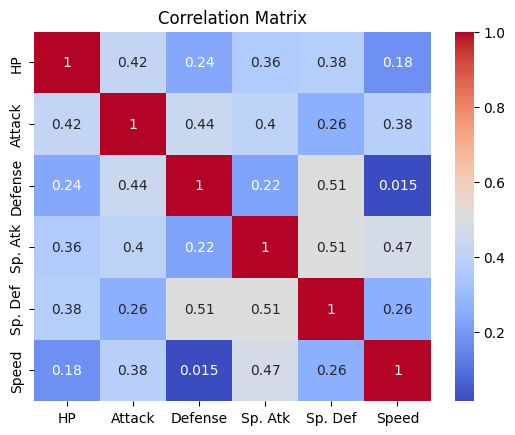

In [41]:
correlation_matrix = new_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [42]:
selected_df = df[['Speed', 'Attack', 'Defense']]
selected_df

,Speed,Attack,Defense
0,45,49,49
1,60,62,63
2,80,82,83
3,80,100,123
4,65,52,43
...,...,...,...
795,50,100,150
796,110,160,110
797,70,110,60
798,80,160,60


Are there any missing values? (2 pts)

In [43]:
selected_df.isnull().sum()

,0
Speed,0
Attack,0
Defense,0


If missing values exist, describe how you handled them (3 pts)

There are **no missing values** on my selected features.

### Data Visualization

In [44]:
fig = px.scatter_3d(selected_df, x='Speed', y='Attack', z='Defense')
fig.show()

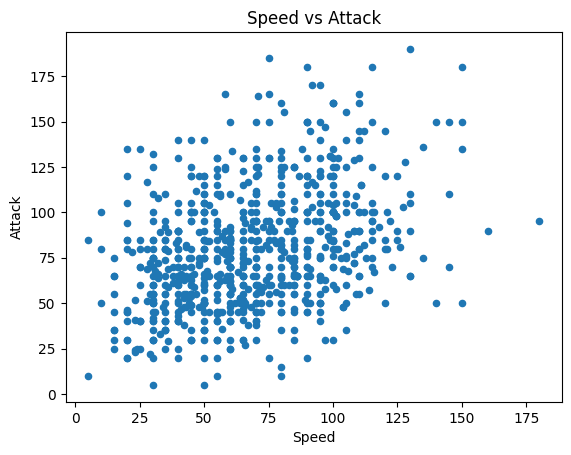

In [45]:
selected_df.plot.scatter(x='Speed', y='Attack')
plt.xlabel('Speed')
plt.ylabel('Attack')
plt.title('Speed vs Attack')
plt.show()

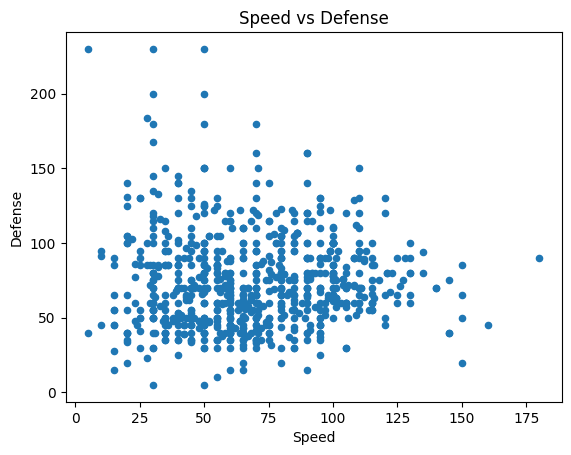

In [46]:
selected_df.plot.scatter(x='Speed', y='Defense')
plt.xlabel('Speed')
plt.ylabel('Defense')
plt.title('Speed vs Defense')
plt.show()

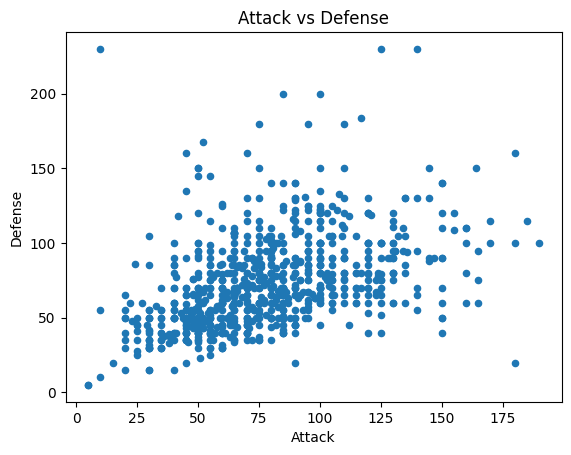

In [47]:
selected_df.plot.scatter(x='Attack', y='Defense')
plt.xlabel('Attack')
plt.ylabel('Defense')
plt.title('Attack vs Defense')
plt.show()

# 3. Scale the Features (10 pts)

Apply StandardScaler to the selected features.

Show the transformed feature sample (e.g., first 5 rows) (10 pts)


In [48]:
scaler = StandardScaler()
selected_df[['Speed', 'Attack', 'Defense']] = scaler.fit_transform(selected_df[['Speed', 'Attack', 'Defense']])
selected_df.head(5)

/tmp/ipython-input-1163823210.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Speed,Attack,Defense
0,-0.801503,-0.924906,-0.797154
1,-0.285015,-0.524130,-0.347917
2,0.403635,0.092448,0.293849
3,0.403635,0.647369,1.577381
4,-0.112853,-0.832419,-0.989683


## 4. Determine a Suitable eps Value (10 pts)

Using k = 4:
Compute the distance to the 4th nearest neighbor for each Pokémon (6 pts)

In [49]:
nn = NearestNeighbors(n_neighbors=4).fit(selected_df)
distances, indices = nn.kneighbors(selected_df)

What is your chosen eps based on the "elbow"? (2 pts)

<function matplotlib.pyplot.show(close=None, block=None)>

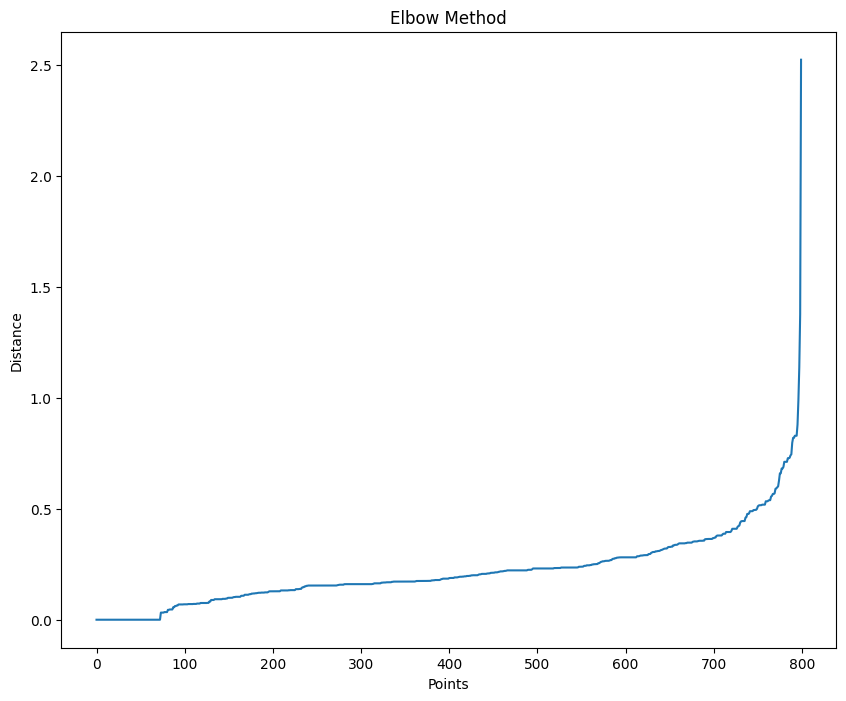

In [50]:
distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.figure(figsize=(10, 8))
plt.plot(distances)
plt.xlabel('Points')
plt.ylabel('Distance')
plt.title('Elbow Method')
plt.show

In [51]:
min_samples = range(3, 8)
min_samples
epsilon = np.arange(0.25, 0.8, 0.05)
epsilon

array([0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55, 0.6 , 0.65, 0.7 , 0.75])

In [52]:
output = []

for ms in min_samples:
  for ep in epsilon:
    labels = DBSCAN(min_samples=ms, eps=ep).fit(selected_df).labels_
    score = metrics.silhouette_score(selected_df, labels)
    output.append((ms, ep, score))

In [53]:
min_samples, eps, score = sorted(output, key=lambda x:x[-1])[-1]
print(f"Best silhouette_score: {score}")
print(f"min_samples: {min_samples}")
print(f"eps: {eps}")

Best silhouette_score: 0.44225972953899423
min_samples: 4
eps: 0.7499999999999999


One-sentence explanation of your reasoning (2 pts)

Using the elbow method graph above, I analyzed it and inputted the value that is close to the "elbow" into my min_samples and eps, then I chose a range then loop them to find the optimal value for both min_samples and eps.

## 5. Run DBSCAN (10 points)

Run DBSCAN using your chosen eps and min_samples


In [54]:
ep = eps
dbscan = DBSCAN(eps = ep, min_samples=min_samples).fit(selected_df)
labels = dbscan.labels_

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)

n_noise_ = list(labels).count(-1)

silhouette_score = metrics.silhouette_score(selected_df, labels)

In [55]:
print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)
print("Silhouette scrore", silhouette_score)

Estimated number of clusters: 1
Estimated number of noise points: 26
Silhouette scrore 0.44225972953899423


How many clusters did DBSCAN find? (4 pts)

Using DBSCAN, I'm able to find only **one (1)** cluster

In [56]:
print(np.unique(labels))

[-1  0]


How many Pokémon were labeled as noise? (4 pts)

A total of **26 Pokémons** are labeled as noise



In [57]:
print(n_noise_)

26


Show the unique labels output by DBSCAN (2 pts)

In [58]:
selected_df['labels'] = labels
fig = px.scatter_3d(selected_df, x='Speed', y='Attack', z='Defense', color='labels')
fig.show()

/tmp/ipython-input-1696149978.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



## 6. Attach Cluster Labels to the Original Dataset (7 points)

Add the cluster labels back to the original DataFrame (3 pts)



In [59]:
df['Cluster'] = labels
df[['Name', 'Speed', 'Attack', 'Defense', 'Cluster']].head()

,Name,Speed,Attack,Defense,Cluster
0,Bulbasaur,45,49,49,0
1,Ivysaur,60,62,63,0
2,Venusaur,80,82,83,0
3,VenusaurMega Venusaur,80,100,123,0
4,Charmander,65,52,43,0


Show the first 10 rows including the cluster label (4 pts)

In [60]:
df[['Name', 'Speed', 'Attack', 'Defense', 'Cluster']].head(10)

,Name,Speed,Attack,Defense,Cluster
0,Bulbasaur,45,49,49,0
1,Ivysaur,60,62,63,0
2,Venusaur,80,82,83,0
3,VenusaurMega Venusaur,80,100,123,0
4,Charmander,65,52,43,0
5,Charmeleon,80,64,58,0
6,Charizard,100,84,78,0
7,CharizardMega Charizard X,100,130,111,0
8,CharizardMega Charizard Y,100,104,78,0
9,Squirtle,43,48,65,0


## 7. Explore the Clusters (12 points)

For each cluster:


How many Pokémon does it contain? (4 pts)

In [61]:
df['Cluster'].value_counts()

,count
Cluster,
0,774
-1,26


What are the average Attack, Defense, and Speed? (4 pts)


In [62]:
df.groupby('Cluster')[['Attack', 'Defense', 'Speed']].mean()

,Attack,Defense,Speed
Cluster,,,
-1,113.538462,115.730769,81.192308
0,77.841085,72.435401,67.843669


Compare the clusters: What differences do you notice? (4 pts)

Unfortunately, I can't compare my cluster since I only have **one (1)** cluster

## 8. Identify Outliers (10 points)

List all Pokémon labeled as noise (cluster = -1) (4 pts)

In [63]:
df[df['Cluster'] == -1][['Name', 'Attack', 'Defense', 'Speed', 'Cluster', 'Legendary']]

,Name,Attack,Defense,Speed,Cluster,Legendary
19,BeedrillMega Beedrill,150,40,145,-1,False
87,SlowbroMega Slowbro,75,180,30,-1,False
98,Cloyster,95,180,70,-1,False
154,AerodactylMega Aerodactyl,135,85,150,-1,False
164,MewtwoMega Mewtwo Y,150,70,140,-1,True
223,Steelix,85,200,30,-1,False
224,SteelixMega Steelix,125,230,30,-1,False
230,Shuckle,10,230,5,-1,False
315,Ninjask,90,45,160,-1,False
332,Aggron,110,180,50,-1,False


Are many of them legendary? (3 pts)

No, there are only **8 legendaries** out of **26 outliers**, which only makes up **30.77%** of the total outliers. It's not even half of the population.

Explain why DBSCAN might classify them as outliers (3 pts)

By comparing their statistics to the mean of Cluster 0, I found some trend. When one or more of the features is vastly greater or lesser than the mean of Cluster 0, it is identified as outlier.

## 9. Interpret the Clustering Results (25 points)
Write a short interpretation (4–6 sentences).
Discuss:


What types of Pokémon grouped together (5 pts)

Since I only have one cluster of Pokémon's, I was only able to have insight by comparing its average features to the outliers. The Cluster 0 has very balanced Attack, Defense, and Speed. It is around 65 - 75 across all metrics. So I say that those with an average of 70 power by using the features Attack, Defense, and Speed, are grouped together. Otherwise, they are considered as outliers.

Whether the clusters make intuitive sense (10 pts)

Frankly, no. From data visualization, I can't really tell any clusters. After using DBSCAN, the cluster that it identified still doesn't make any sense. But out of all the number of cluster, the 1 cluster makes the most sense, that's why I chose it. But generally speaking, the dataset is quite hard to cluster. Maybe it's because of the features that I used?


What the noise points reveal about DBSCAN (5 pts)


Since the mean of outliers is vastly greater than the Cluster 0, it reveals that if the mean is not close to any cluster, DBSCAN will identify it as an outlier. It will not try to create a cluster when the data point is not close to other data points. This prevents skewing of the data which is very important when training a model. By doing this, we can prevent bias.

What stat patterns you discovered (5 pts)

The stat patters that I discovered are: First is that most of the Pokémon has an average of 70 in terms of Attack, Defense, and Speed. That's 96.75% of the total Pokémons! Next is that not all legendaries has higher stats than the common Pokémon. Based on my data, only 30.77% of outliers are legendary. Outliers has higher mean across the board.